## ResNet vs ViT Model Comparison
Compare performance of ResNet and ViT models across different road surface classes

In [65]:
import os, sys, json
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support
from tqdm import tqdm
from PIL import Image
import random

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from src.models.resnet_cnn import create_resnet18
from src.models.vit_transformer import get_vit
from src.datasets.road_loader import sample_road_surface_dataset

In [66]:
# Set up device
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

# Load dataset
base_data = Path('../data/road_surface/RSCD dataset-1million')
sampled_data = Path('../data/road_surface/RSCD_sampled')
if not sampled_data.exists():
    print('Creating sampled dataset...')
    from src.datasets.road_loader import sample_road_surface_dataset
    sample_road_surface_dataset(base_data, sampled_data, train_per_class=160, val_per_class=3, test_per_class=10)
    print('Sampling complete!')
else:
    print(f'Sampled dataset already exists at {sampled_data}')

# Load transforms and test dataset
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(root=sampled_data/'test', transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)
class_names = test_dataset.classes
num_classes = len(class_names)

print(f'Number of classes: {num_classes}')
print(f'Test samples: {len(test_dataset)}')

Using device: mps
Sampled dataset already exists at ../data/road_surface/RSCD_sampled
Number of classes: 27
Test samples: 270


In [67]:
# Function to get predictions from model
def get_predictions(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_confidences = []
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Testing', unit='batch'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)
            confidences = torch.max(probs, dim=1)[0]
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_confidences.extend(confidences.cpu().numpy())
    
    return np.array(all_preds), np.array(all_labels), np.array(all_confidences)

In [68]:
# Load ResNet model
resnet_model = create_resnet18(num_classes=num_classes)
if os.path.exists('best_road_surface_model.pth'):
    resnet_model.load_state_dict(torch.load('best_road_surface_model.pth'))
    print('Loaded ResNet model')
else:
    print('ResNet model not found')
resnet_model.to(device)

# Get ResNet predictions
resnet_preds, test_labels, resnet_confidences = get_predictions(resnet_model, test_loader, device)

Loaded ResNet model


Testing: 100%|██████████| 17/17 [00:00<00:00, 18.78batch/s]


In [69]:
# Load ViT model
vit_model = get_vit(num_classes, pretrained=False)
if os.path.exists('best_vit_model.pth'):
    vit_model.load_state_dict(torch.load('best_vit_model.pth'))
    print('Loaded ViT model')
else:
    print('ViT model not found')
vit_model.to(device)

# Get ViT predictions
vit_preds, _, vit_confidences = get_predictions(vit_model, test_loader, device)

Loaded ViT model


Testing: 100%|██████████| 17/17 [00:00<00:00, 25.30batch/s]


In [70]:
# Per-class performance metrics
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# ResNet metrics
resnet_precision, resnet_recall, resnet_f1, _ = precision_recall_fscore_support(test_labels, resnet_preds, average=None)
resnet_accuracy = accuracy_score(test_labels, resnet_preds)
resnet_per_class_acc = confusion_matrix(test_labels, resnet_preds).diagonal() / confusion_matrix(test_labels, resnet_preds).sum(axis=1)

# ViT metrics
vit_precision, vit_recall, vit_f1, _ = precision_recall_fscore_support(test_labels, vit_preds, average=None)
vit_accuracy = accuracy_score(test_labels, vit_preds)
vit_per_class_acc = confusion_matrix(test_labels, vit_preds).diagonal() / confusion_matrix(test_labels, vit_preds).sum(axis=1)

print(f'ResNet Accuracy: {resnet_accuracy:.4f}')
print(f'ViT Accuracy: {vit_accuracy:.4f}')

ResNet Accuracy: 0.5222
ViT Accuracy: 0.4407


In [71]:
# Calculate test loss for both models
criterion = nn.CrossEntropyLoss()

# ResNet test loss
resnet_model.eval()
resnet_test_loss = 0.0
resnet_test_correct = 0
resnet_test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = resnet_model(images)
        loss = criterion(outputs, labels)
        resnet_test_loss += loss.item() * images.size(0)
        resnet_test_correct += (outputs.argmax(1) == labels).sum().item()
        resnet_test_total += labels.size(0)

resnet_test_loss = resnet_test_loss / resnet_test_total
resnet_test_acc = resnet_test_correct / resnet_test_total * 100

# ViT test loss
vit_model.eval()
vit_test_loss = 0.0
vit_test_correct = 0
vit_test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = vit_model(images)
        loss = criterion(outputs, labels)
        vit_test_loss += loss.item() * images.size(0)
        vit_test_correct += (outputs.argmax(1) == labels).sum().item()
        vit_test_total += labels.size(0)

vit_test_loss = vit_test_loss / vit_test_total
vit_test_acc = vit_test_correct / vit_test_total * 100

# Print results
print("="*60)
print("TEST SET PERFORMANCE COMPARISON")
print("="*60)
print(f"\nResNet:")
print(f"  Test Loss:     {resnet_test_loss:.4f}")
print(f"  Test Accuracy: {resnet_test_acc:.2f}%")
print(f"\nViT:")
print(f"  Test Loss:     {vit_test_loss:.4f}")
print(f"  Test Accuracy: {vit_test_acc:.2f}%")
print(f"\nWinner:")
print(f"  Accuracy: {'ResNet' if resnet_test_acc > vit_test_acc else 'ViT'} by {abs(resnet_test_acc - vit_test_acc):.2f}%")
print(f"  Loss:     {'ResNet' if resnet_test_loss < vit_test_loss else 'ViT'} by {abs(resnet_test_loss - vit_test_loss):.4f}")
print("="*60)

TEST SET PERFORMANCE COMPARISON

ResNet:
  Test Loss:     1.4962
  Test Accuracy: 52.22%

ViT:
  Test Loss:     1.8349
  Test Accuracy: 44.07%

Winner:
  Accuracy: ResNet by 8.15%
  Loss:     ResNet by 0.3387


In [72]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Class': class_names,
    'ResNet Accuracy': resnet_per_class_acc,
    'ViT Accuracy': vit_per_class_acc,
    'ResNet Precision': resnet_precision,
    'ViT Precision': vit_precision,
    'ResNet Recall': resnet_recall,
    'ViT Recall': vit_recall,
    'ResNet F1': resnet_f1,
    'ViT F1': vit_f1
})

# Add difference column
comparison_df['Accuracy Diff (ResNet - ViT)'] = comparison_df['ResNet Accuracy'] - comparison_df['ViT Accuracy']

# Sort by accuracy difference
comparison_df_sorted = comparison_df.sort_values('Accuracy Diff (ResNet - ViT)', ascending=False)

print(comparison_df_sorted.to_string())

                    Class  ResNet Accuracy  ViT Accuracy  ResNet Precision  ViT Precision  ResNet Recall  ViT Recall  ResNet F1    ViT F1  Accuracy Diff (ResNet - ViT)
11   water-asphalt-severe              0.7           0.1          0.777778       0.100000            0.7         0.1   0.736842  0.100000                           0.6
6              dry-gravel              0.5           0.1          0.555556       0.333333            0.5         0.1   0.526316  0.153846                           0.4
7                 dry-mud              0.7           0.3          0.500000       0.300000            0.7         0.3   0.583333  0.300000                           0.4
26                wet-mud              0.6           0.3          0.666667       0.272727            0.6         0.3   0.631579  0.285714                           0.3
0      dry-asphalt-severe              0.8           0.6          0.666667       0.428571            0.8         0.6   0.727273  0.500000                       

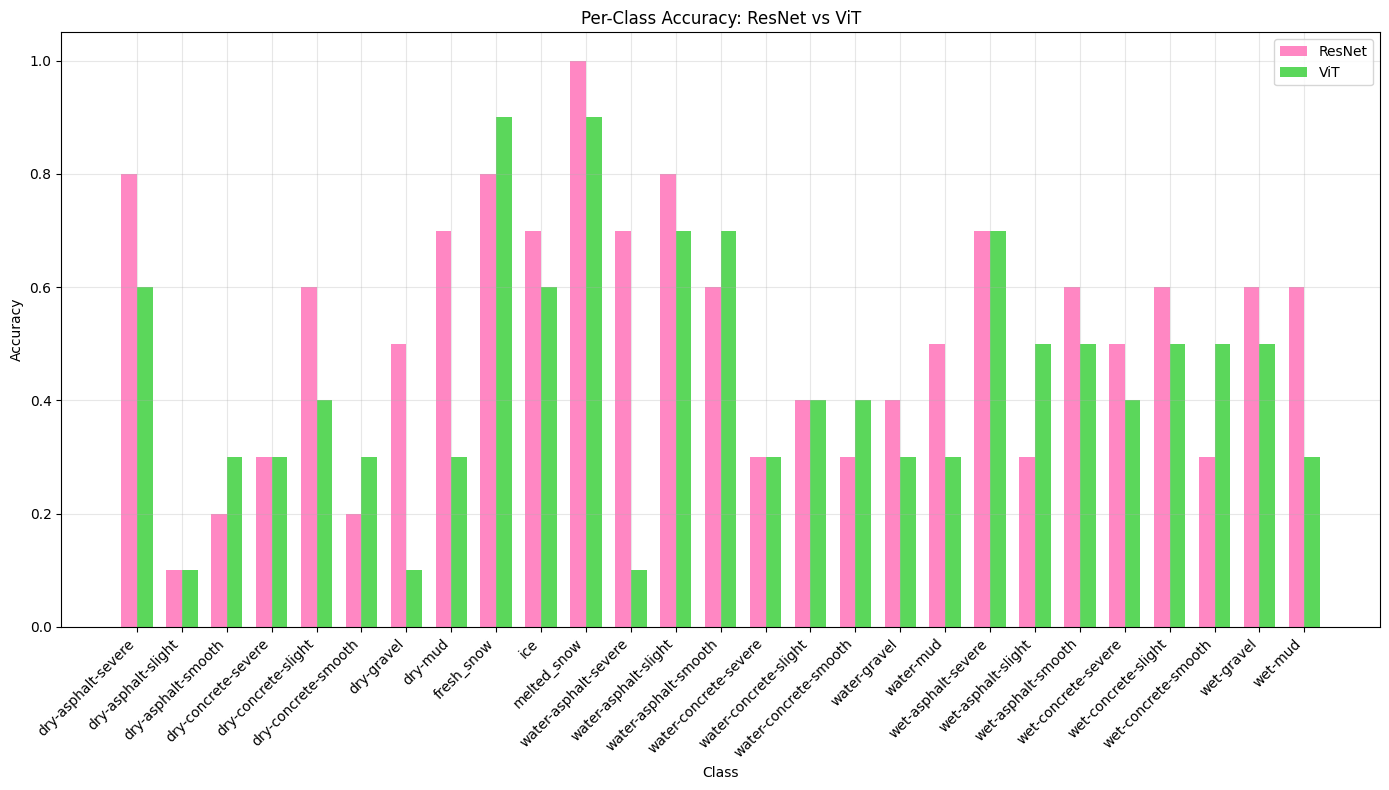

In [73]:
# Visualize per-class accuracy comparison
fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(class_names))
width = 0.35

bars1 = ax.bar(x - width/2, resnet_per_class_acc, width, label='ResNet', color='hotpink', alpha=0.8)
bars2 = ax.bar(x + width/2, vit_per_class_acc, width, label='ViT', color='limegreen', alpha=0.8)

ax.set_xlabel('Class')
ax.set_ylabel('Accuracy')
ax.set_title('Per-Class Accuracy: ResNet vs ViT')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

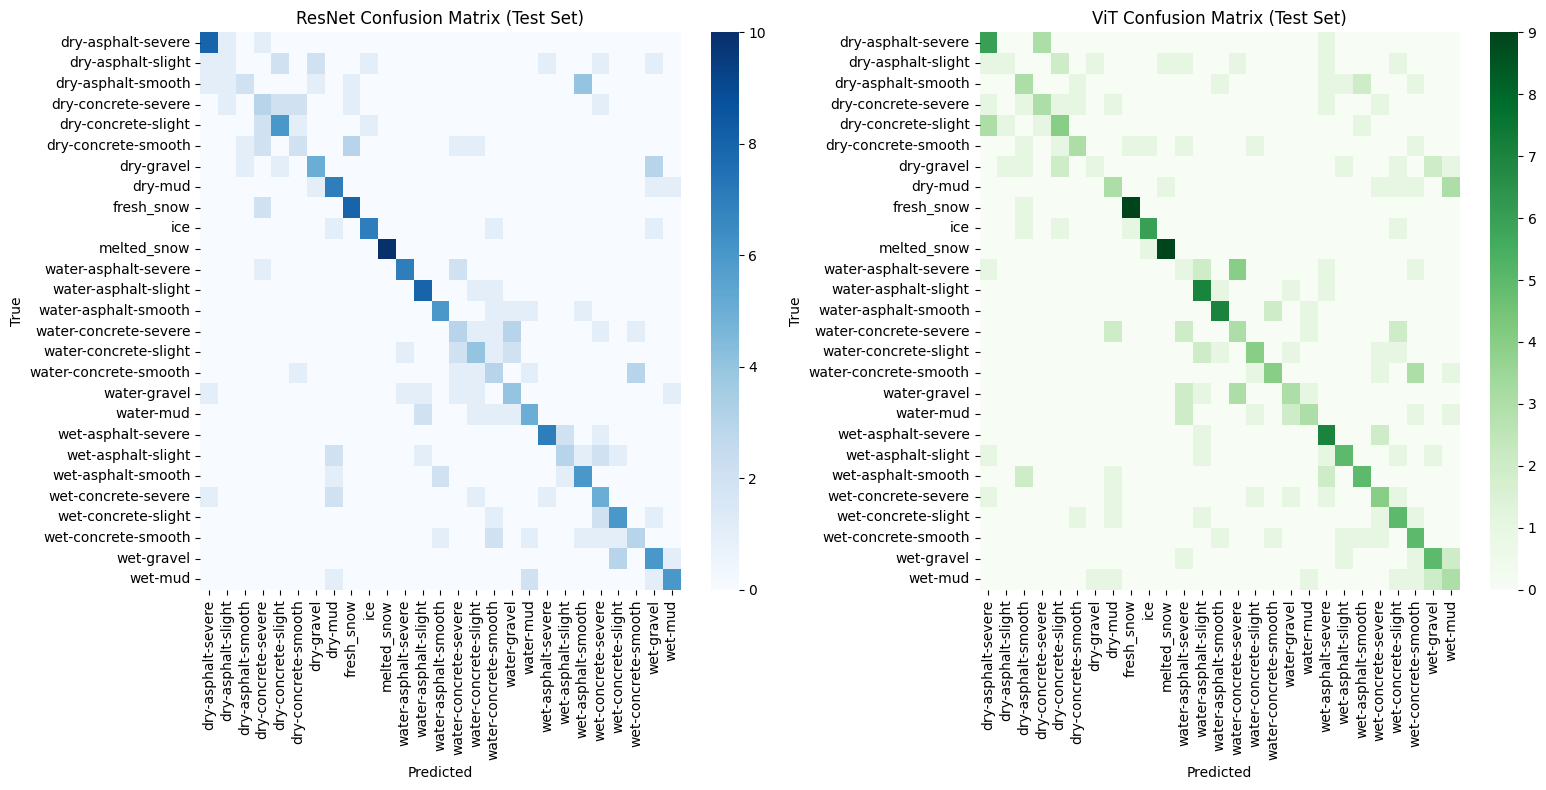

In [74]:
# Confusion matrices side by side
resnet_cm = confusion_matrix(test_labels, resnet_preds)
vit_cm = confusion_matrix(test_labels, vit_preds)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

sns.heatmap(resnet_cm, annot=False, cmap='Blues', cbar=True, ax=ax1, xticklabels=class_names, yticklabels=class_names)
ax1.set_title('ResNet Confusion Matrix (Test Set)')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('True')

sns.heatmap(vit_cm, annot=False, cmap='Greens', cbar=True, ax=ax2, xticklabels=class_names, yticklabels=class_names)
ax2.set_title('ViT Confusion Matrix (Test Set)')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')

plt.tight_layout()
plt.show()

In [75]:
# Find classes where ResNet is better
resnet_better = comparison_df[comparison_df['Accuracy Diff (ResNet - ViT)'] > 0.05].sort_values('Accuracy Diff (ResNet - ViT)', ascending=False)
vit_better = comparison_df[comparison_df['Accuracy Diff (ResNet - ViT)'] < -0.05].sort_values('Accuracy Diff (ResNet - ViT)')

print('Classes where ResNet performs significantly better (>5%):'),
print(resnet_better[['Class', 'ResNet Accuracy', 'ViT Accuracy', 'Accuracy Diff (ResNet - ViT)']].to_string())

print('\nClasses where ViT performs significantly better (>5%):'),
print(vit_better[['Class', 'ResNet Accuracy', 'ViT Accuracy', 'Accuracy Diff (ResNet - ViT)']].to_string())

Classes where ResNet performs significantly better (>5%):
                   Class  ResNet Accuracy  ViT Accuracy  Accuracy Diff (ResNet - ViT)
11  water-asphalt-severe              0.7           0.1                           0.6
6             dry-gravel              0.5           0.1                           0.4
7                dry-mud              0.7           0.3                           0.4
26               wet-mud              0.6           0.3                           0.3
0     dry-asphalt-severe              0.8           0.6                           0.2
18             water-mud              0.5           0.3                           0.2
4    dry-concrete-slight              0.6           0.4                           0.2
12  water-asphalt-slight              0.8           0.7                           0.1
17          water-gravel              0.4           0.3                           0.1
9                    ice              0.7           0.6                           

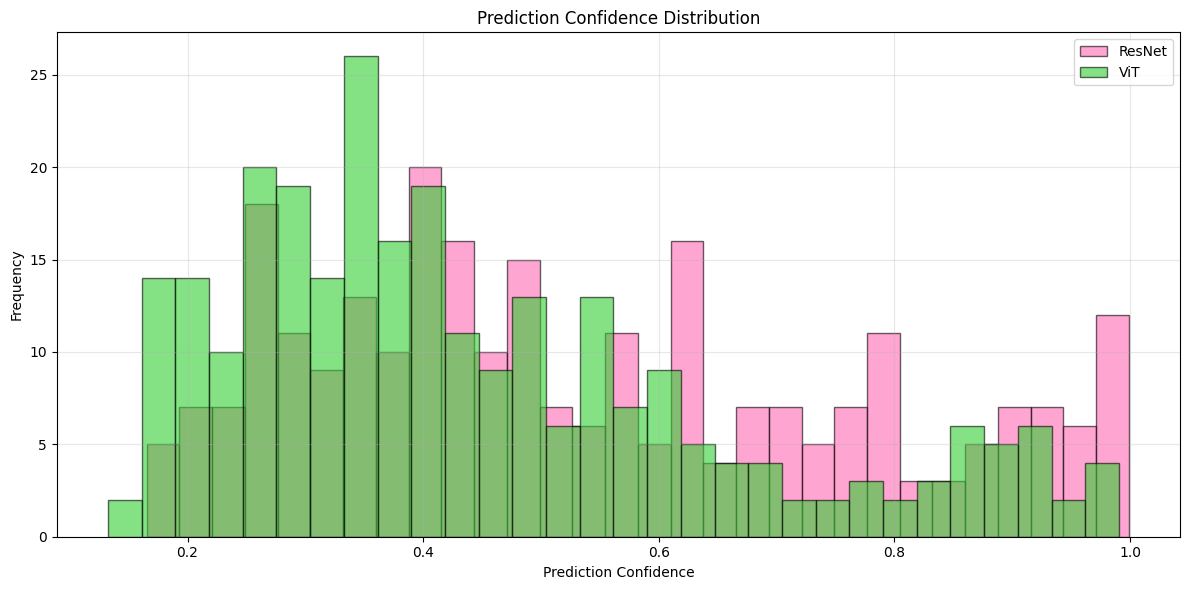

ResNet mean confidence: 0.5391
ViT mean confidence: 0.4434


In [76]:
# Prediction confidence comparison
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(resnet_confidences, bins=30, alpha=0.6, label='ResNet', color='hotpink', edgecolor='black')
ax.hist(vit_confidences, bins=30, alpha=0.6, label='ViT', color='limegreen', edgecolor='black')
ax.set_xlabel('Prediction Confidence')
ax.set_ylabel('Frequency')
ax.set_title('Prediction Confidence Distribution')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'ResNet mean confidence: {resnet_confidences.mean():.4f}')
print(f'ViT mean confidence: {vit_confidences.mean():.4f}')

## Visual Comparison: Where Each Model Excels

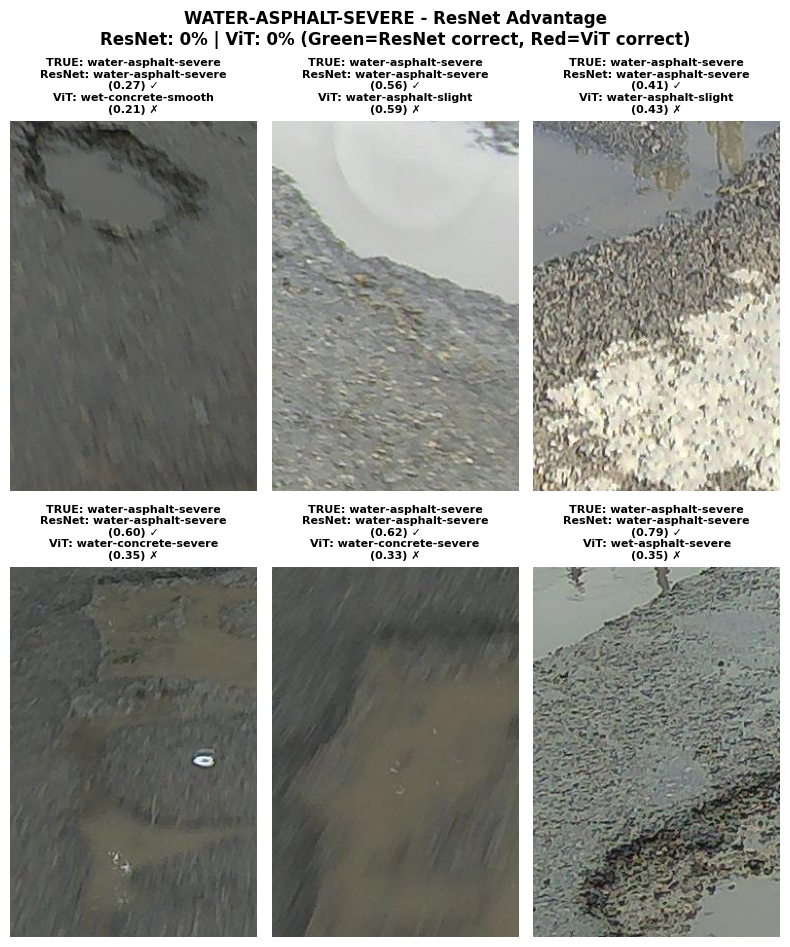

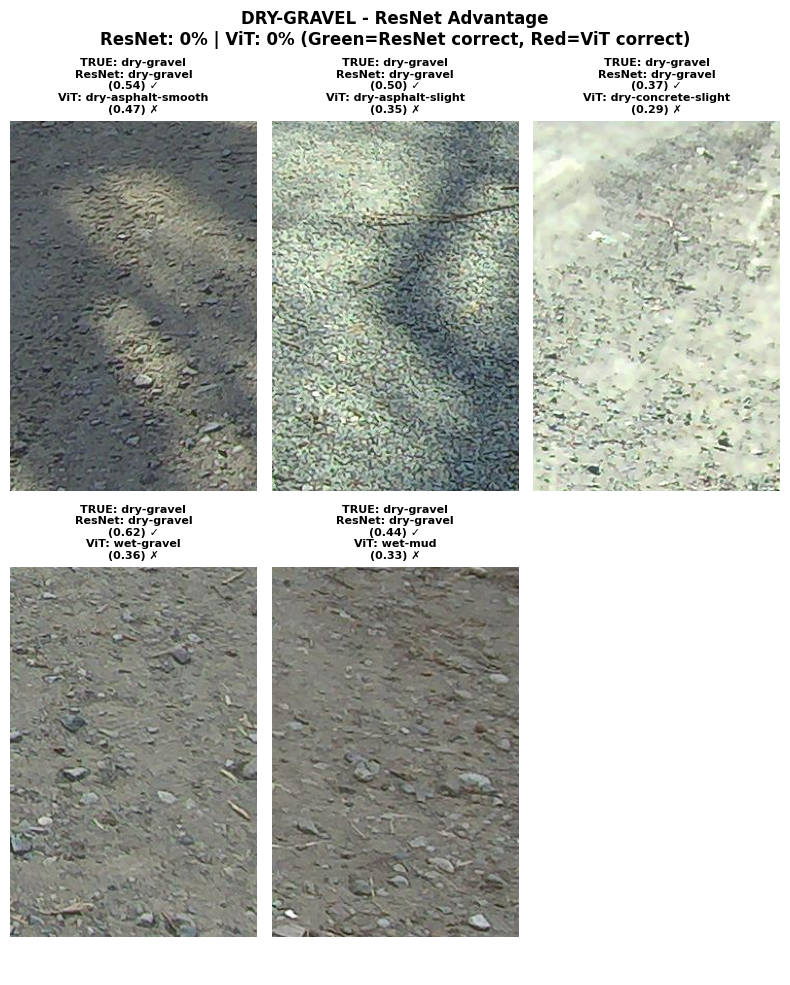

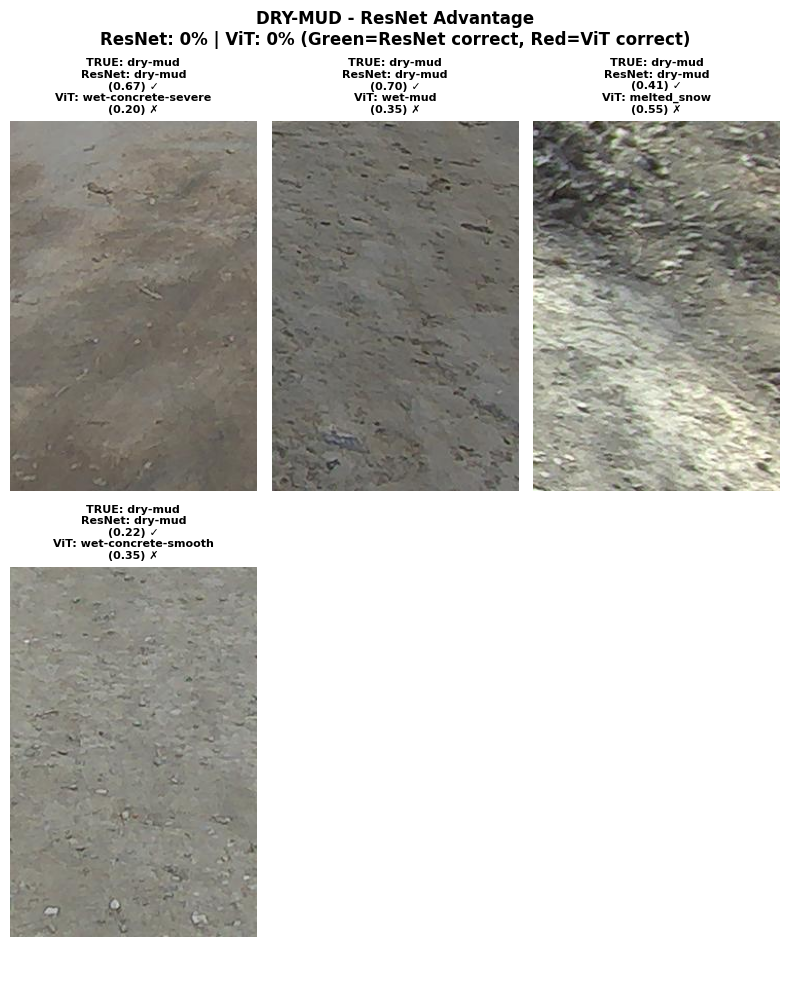

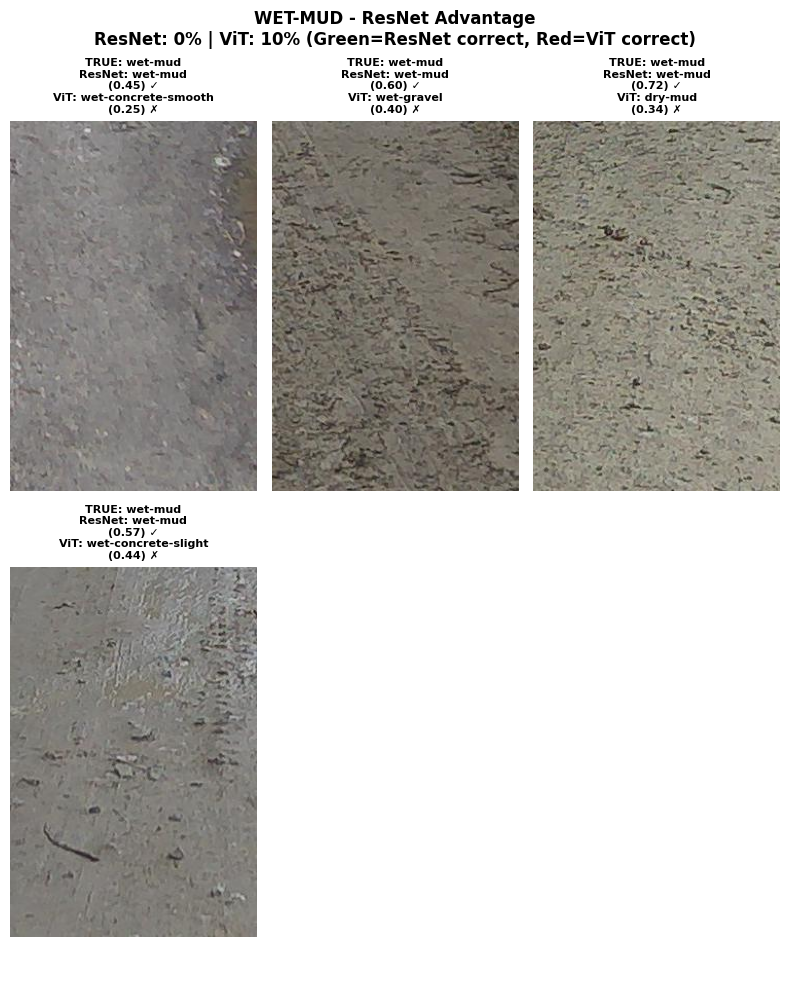

In [83]:
# ResNet Advantages: Rough/Textured Surfaces
resnet_better_classes = ['water-asphalt-severe', 'dry-gravel', 'dry-mud', 'wet-mud']

for target_class in resnet_better_classes:
    try:
        target_idx = class_names.index(target_class)
    except ValueError:
        print(f"Class {target_class} not found")
        continue
    
    # Get all samples of this class
    all_class_indices = np.where(test_labels == target_idx)[0]
    
    # Filter to only where ResNet correct AND ViT incorrect
    resnet_correct_mask = resnet_preds[all_class_indices] == target_idx
    vit_incorrect_mask = vit_preds[all_class_indices] != target_idx
    filtered_indices = all_class_indices[resnet_correct_mask & vit_incorrect_mask]
    
    if len(filtered_indices) == 0:
        print(f"No instances where ResNet correct and ViT wrong for {target_class}")
        continue
    
    # Show 6 examples in compact grid
    num_to_show = min(6, len(filtered_indices))
    fig, axes = plt.subplots(2, 3, figsize=(8, 10))
    axes = axes.flatten()
    
    for idx_plot, sample_idx in enumerate(filtered_indices[:num_to_show]):
        image_path, _ = test_dataset.imgs[sample_idx]
        image = Image.open(image_path)
        
        resnet_pred_idx = resnet_preds[sample_idx]
        vit_pred_idx = vit_preds[sample_idx]
        resnet_pred_name = class_names[resnet_pred_idx]
        vit_pred_name = class_names[vit_pred_idx]
        
        resnet_conf = resnet_confidences[sample_idx]
        vit_conf = vit_confidences[sample_idx]
        
        ax = axes[idx_plot]
        ax.imshow(image)
        ax.axis('off')
        
        # Always green border (ResNet correct)
        for spine in ax.spines.values():
            spine.set_edgecolor('lime')
            spine.set_linewidth(3)
            spine.set_visible(True)
        
        title = f"TRUE: {target_class}\n"
        title += f"ResNet: {resnet_pred_name}\n({resnet_conf:.2f}) ✓\n"
        title += f"ViT: {vit_pred_name}\n({vit_conf:.2f}) ✗"
        ax.set_title(title, fontsize=8, fontweight='bold')
    
    for idx in range(num_to_show, 6):
        axes[idx].axis('off')
    
    resnet_acc = (resnet_preds[class_indices] == target_idx).sum() / len(class_indices) * 100
    vit_acc = (vit_preds[class_indices] == target_idx).sum() / len(class_indices) * 100
    
    fig.suptitle(f'{target_class.upper()} - ResNet Advantage\nResNet: {resnet_acc:.0f}% | ViT: {vit_acc:.0f}% (Green=ResNet correct, Red=ViT correct)', 
                 fontsize=12, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

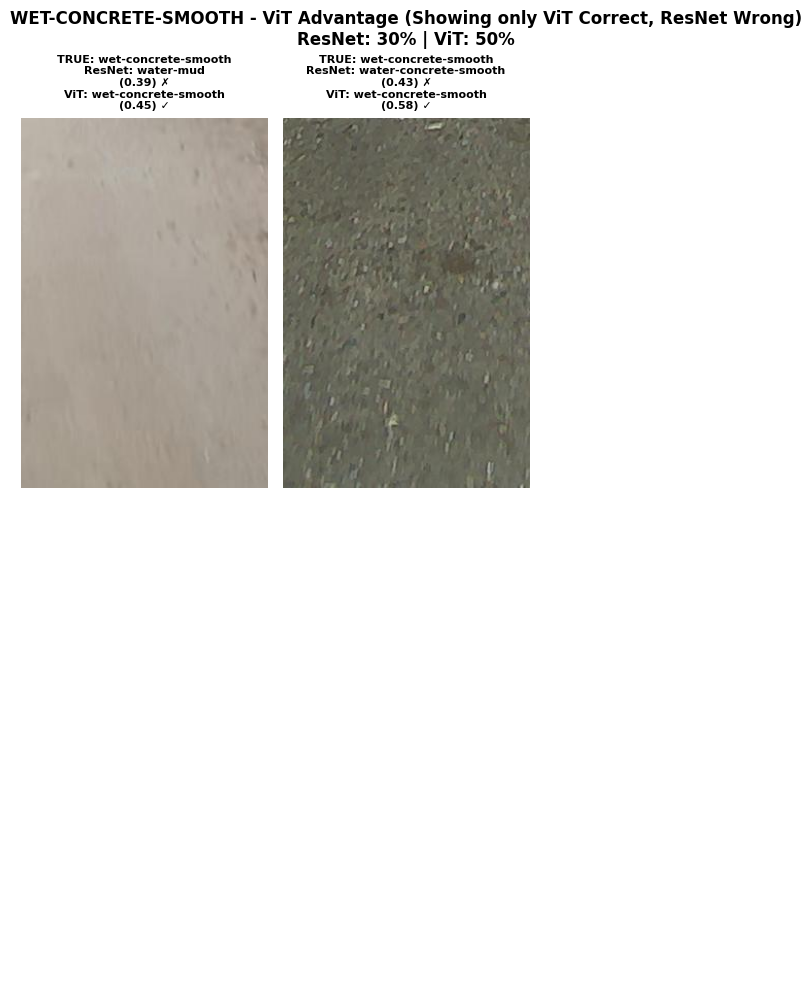

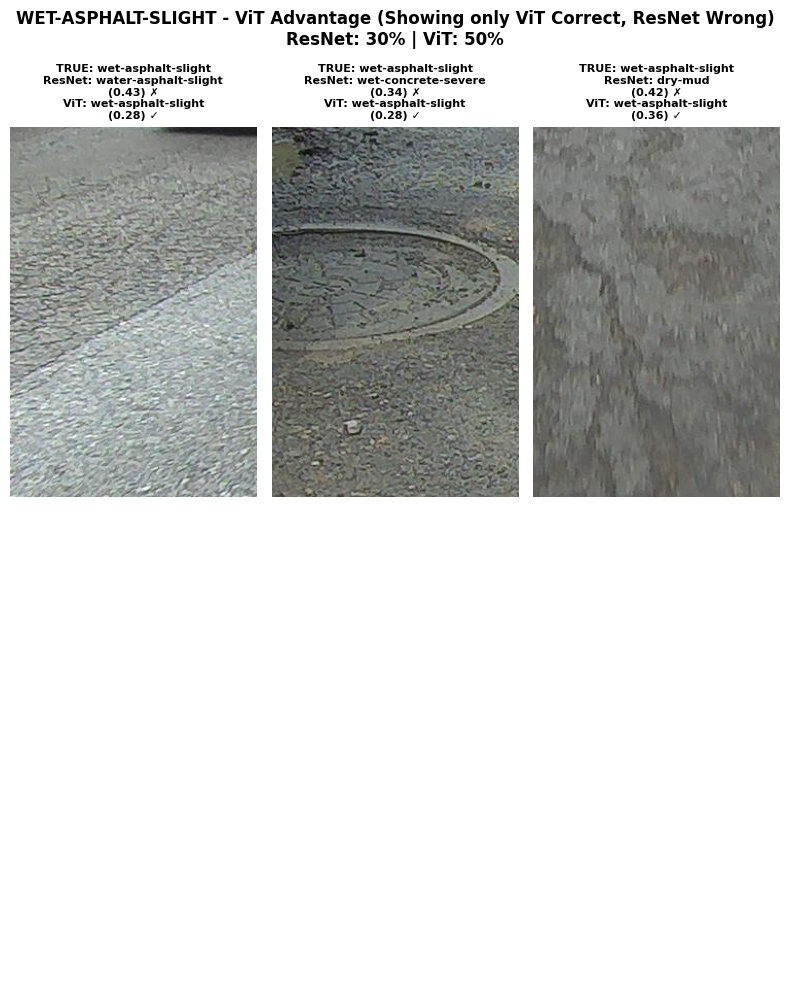

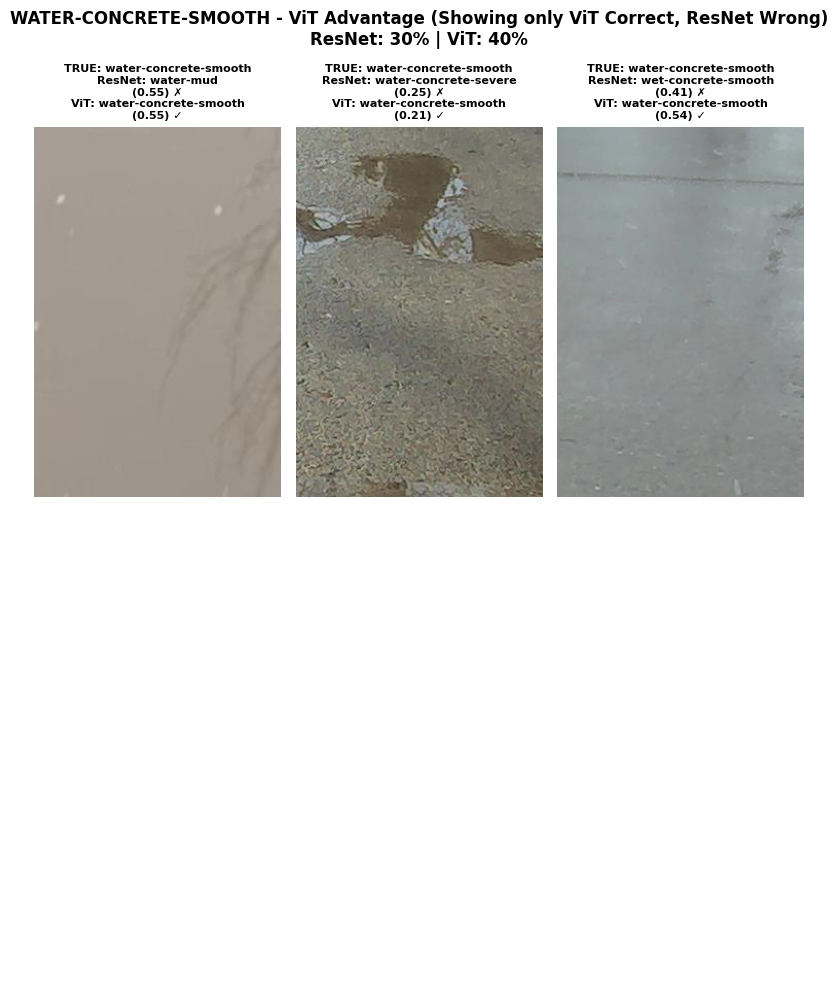

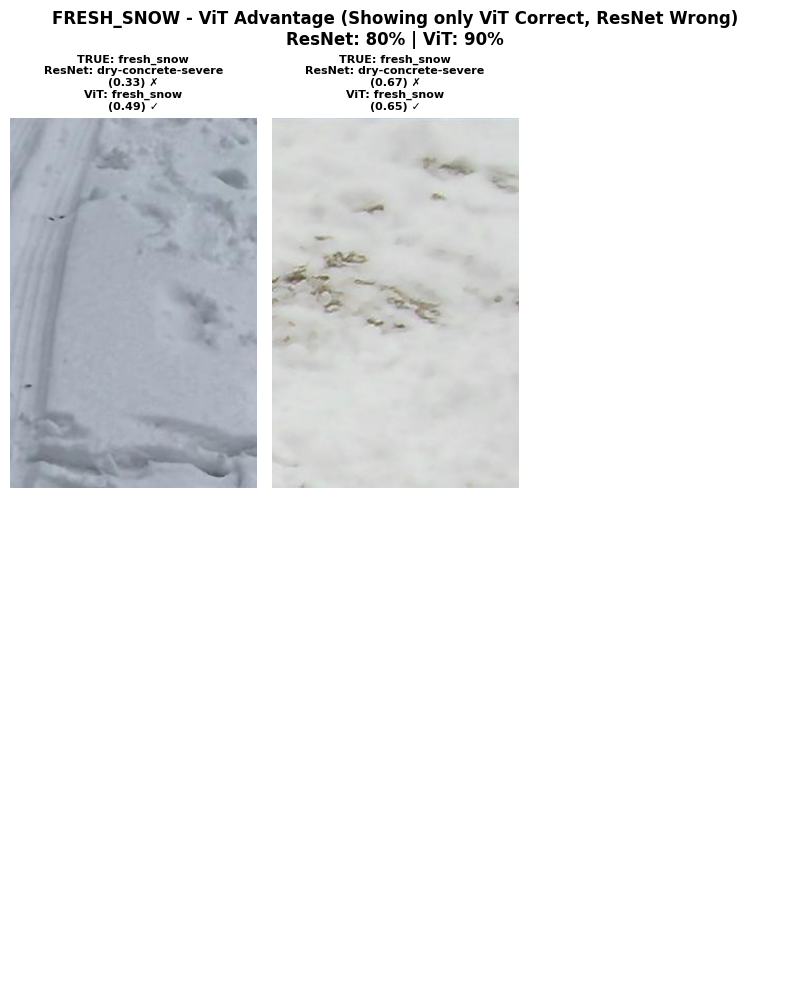

In [85]:
# ViT Advantages: Smooth/Uniform Surfaces
vit_better_classes = ['wet-concrete-smooth', 'wet-asphalt-slight', 'water-concrete-smooth', 'fresh_snow']

for target_class in vit_better_classes:
    try:
        target_idx = class_names.index(target_class)
    except ValueError:
        # Try alternative naming
        alt_name = target_class.replace('-', '_')
        try:
            target_idx = class_names.index(alt_name)
            target_class = alt_name
        except ValueError:
            print(f"Class {target_class} not found")
            continue
    
    # Get all samples of this class
    all_class_indices = np.where(test_labels == target_idx)[0]
    
    # Filter to only where ViT correct AND ResNet incorrect
    vit_correct_mask = vit_preds[all_class_indices] == target_idx
    resnet_incorrect_mask = resnet_preds[all_class_indices] != target_idx
    filtered_indices = all_class_indices[vit_correct_mask & resnet_incorrect_mask]
    
    if len(filtered_indices) == 0:
        print(f"No instances where ViT correct and ResNet wrong for {target_class}")
        continue
    
    # Show 6 examples in compact grid
    num_to_show = min(6, len(filtered_indices))
    fig, axes = plt.subplots(2, 3, figsize=(8, 10))
    axes = axes.flatten()
    
    for idx_plot, sample_idx in enumerate(filtered_indices[:num_to_show]):
        image_path, _ = test_dataset.imgs[sample_idx]
        image = Image.open(image_path)
        
        resnet_pred_idx = resnet_preds[sample_idx]
        vit_pred_idx = vit_preds[sample_idx]
        resnet_pred_name = class_names[resnet_pred_idx]
        vit_pred_name = class_names[vit_pred_idx]
        
        resnet_conf = resnet_confidences[sample_idx]
        vit_conf = vit_confidences[sample_idx]
        
        ax = axes[idx_plot]
        ax.imshow(image)
        ax.axis('off')
        
        # Always green border (ViT correct)
        for spine in ax.spines.values():
            spine.set_edgecolor('lime')
            spine.set_linewidth(3)
            spine.set_visible(True)
        
        title = f"TRUE: {target_class}\n"
        title += f"ResNet: {resnet_pred_name}\n({resnet_conf:.2f}) ✗\n"
        title += f"ViT: {vit_pred_name}\n({vit_conf:.2f}) ✓"
        ax.set_title(title, fontsize=8, fontweight='bold')
    
    for idx in range(num_to_show, 6):
        axes[idx].axis('off')
    
    resnet_acc = (resnet_preds[all_class_indices] == target_idx).sum() / len(all_class_indices) * 100
    vit_acc = (vit_preds[all_class_indices] == target_idx).sum() / len(all_class_indices) * 100
    
    fig.suptitle(f'{target_class.upper()} - ViT Advantage (Showing only ViT Correct, ResNet Wrong)\nResNet: {resnet_acc:.0f}% | ViT: {vit_acc:.0f}%', 
                 fontsize=12, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

Found 6 samples where ResNet correct, ViT wrong


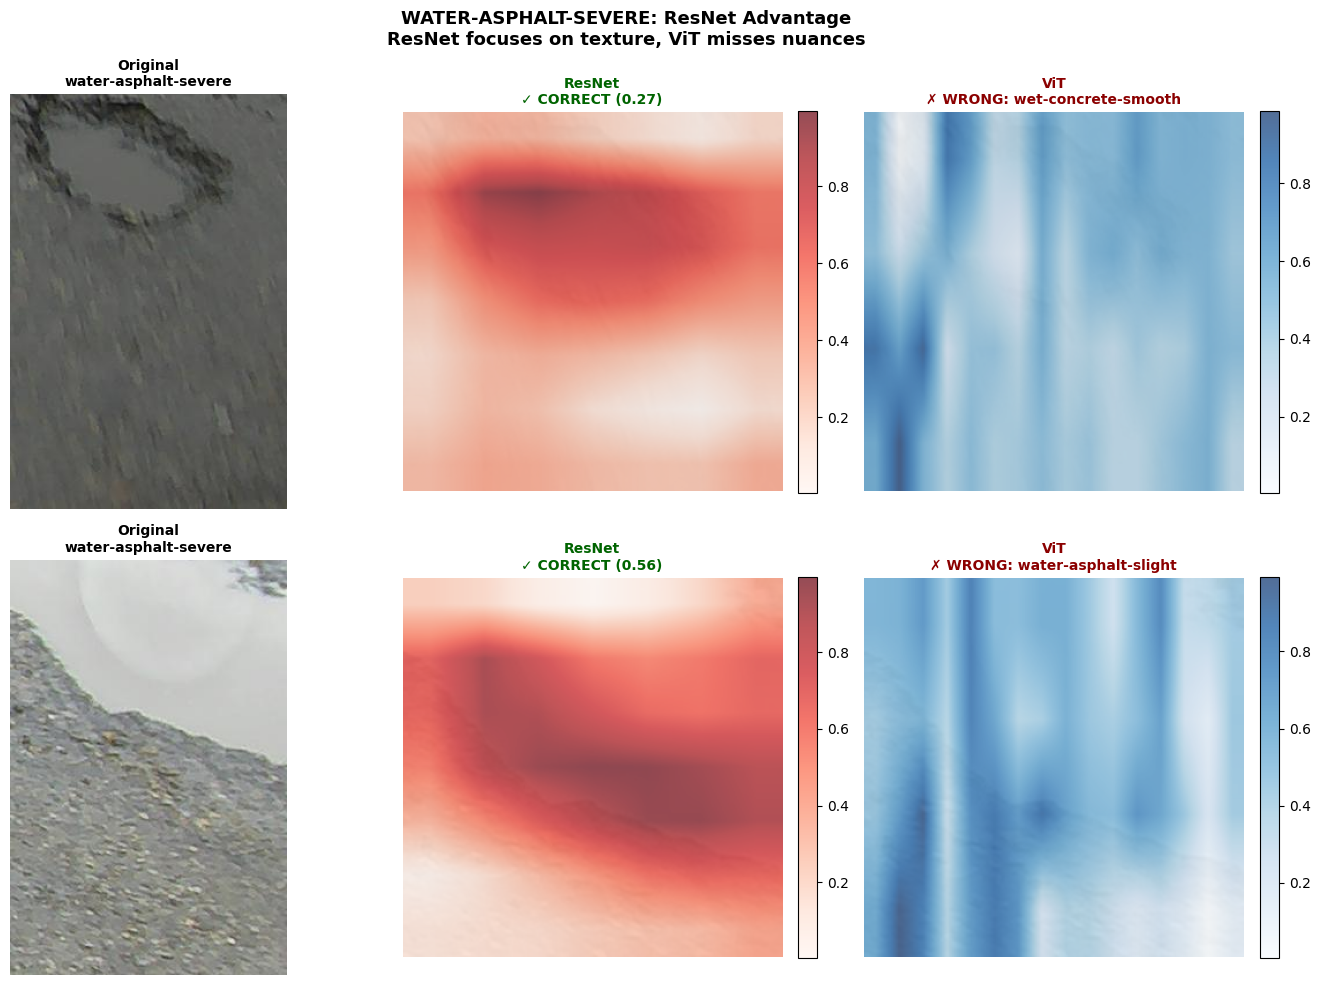

In [96]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from torchvision import transforms

def get_resnet_attention(model, image_tensor, device):
    activations = []
    def hook_fn(module, input, output):
        activations.append(output.detach())
    handle = model.backbone.layer4[-1].conv2.register_forward_hook(hook_fn)
    with torch.no_grad():
        _ = model(image_tensor)
    handle.remove()
    if activations:
        feat_map = activations[0][0]
        attention = feat_map.mean(dim=0).cpu().numpy()
        attention = (attention - attention.min()) / (attention.max() - attention.min() + 1e-8)
        return attention
    return None

def get_vit_attention(model, image_tensor, device):
    activations = []
    def hook_fn(module, input, output):
        activations.append(output.detach())
    handle = model.stages[4][1].transformer[-1].attn.register_forward_hook(hook_fn)
    with torch.no_grad():
        _ = model(image_tensor)
    handle.remove()
    if activations:
        attn_map = activations[0][0].mean(dim=0).cpu().numpy()
        attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)
        return attn_map
    return None

target_class = 'water-asphalt-severe'
target_idx = class_names.index(target_class)
all_class_indices = np.where(test_labels == target_idx)[0]
resnet_correct_mask = resnet_preds[all_class_indices] == target_idx
vit_incorrect_mask = vit_preds[all_class_indices] != target_idx
filtered_indices = all_class_indices[resnet_correct_mask & vit_incorrect_mask]

print(f"Found {len(filtered_indices)} samples where ResNet correct, ViT wrong")

if len(filtered_indices) > 0:
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    num_to_show = min(2, len(filtered_indices))
    fig, axes = plt.subplots(num_to_show, 3, figsize=(14, 5*num_to_show))
    if num_to_show == 1:
        axes = axes.reshape(1, -1)
    
    for row_idx, sample_idx in enumerate(filtered_indices[:num_to_show]):
        img_path, _ = test_dataset.imgs[sample_idx]
        image_pil = Image.open(img_path).convert('RGB')
        image_tensor = val_transform(image_pil).unsqueeze(0).to(device)
        
        resnet_pred_idx = resnet_preds[sample_idx]
        vit_pred_idx = vit_preds[sample_idx]
        resnet_conf = resnet_confidences[sample_idx]
        vit_conf = vit_confidences[sample_idx]
        
        # Column 1: Original Image
        ax = axes[row_idx, 0]
        ax.imshow(image_pil)
        ax.set_title(f"Original\n{target_class}", fontweight='bold', fontsize=10)
        ax.axis('off')
        
        # Column 2: ResNet Attention
        ax = axes[row_idx, 1]
        try:
            resnet_attention = get_resnet_attention(resnet_model, image_tensor, device)
            if resnet_attention is not None:
                resnet_attention_resized = F.interpolate(
                    torch.from_numpy(resnet_attention).unsqueeze(0).unsqueeze(0).float(),
                    size=(224, 224), mode='bilinear'
                ).squeeze().numpy()
                ax.imshow(image_pil, alpha=0.3)
                im = ax.imshow(resnet_attention_resized, cmap='Reds', alpha=0.7)
                ax.set_title(f"ResNet\n✓ CORRECT ({resnet_conf:.2f})", 
                            fontweight='bold', fontsize=10, color='darkgreen')
                plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        except Exception as e:
            ax.imshow(image_pil)
            ax.set_title(f"ResNet\n✓ CORRECT", fontweight='bold', fontsize=10, color='darkgreen')
        ax.axis('off')
        
        # Column 3: ViT Attention
        ax = axes[row_idx, 2]
        try:
            vit_attention = get_vit_attention(vit_model, image_tensor, device)
            if vit_attention is not None:
                vit_attention_resized = F.interpolate(
                    torch.from_numpy(vit_attention).unsqueeze(0).unsqueeze(0).float(),
                    size=(224, 224), mode='bilinear'
                ).squeeze().numpy()
                ax.imshow(image_pil, alpha=0.3)
                im = ax.imshow(vit_attention_resized, cmap='Blues', alpha=0.7)
                ax.set_title(f"ViT\n✗ WRONG: {class_names[vit_pred_idx]}", 
                            fontweight='bold', fontsize=10, color='darkred')
                plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        except Exception as e:
            ax.imshow(image_pil)
            ax.set_title(f"ViT\n✗ WRONG", fontweight='bold', fontsize=10, color='darkred')
        ax.axis('off')
    
    fig.suptitle(f'{target_class.upper()}: ResNet Advantage\nResNet focuses on texture, ViT misses nuances', 
                fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

Found 2 samples where ViT correct, ResNet wrong


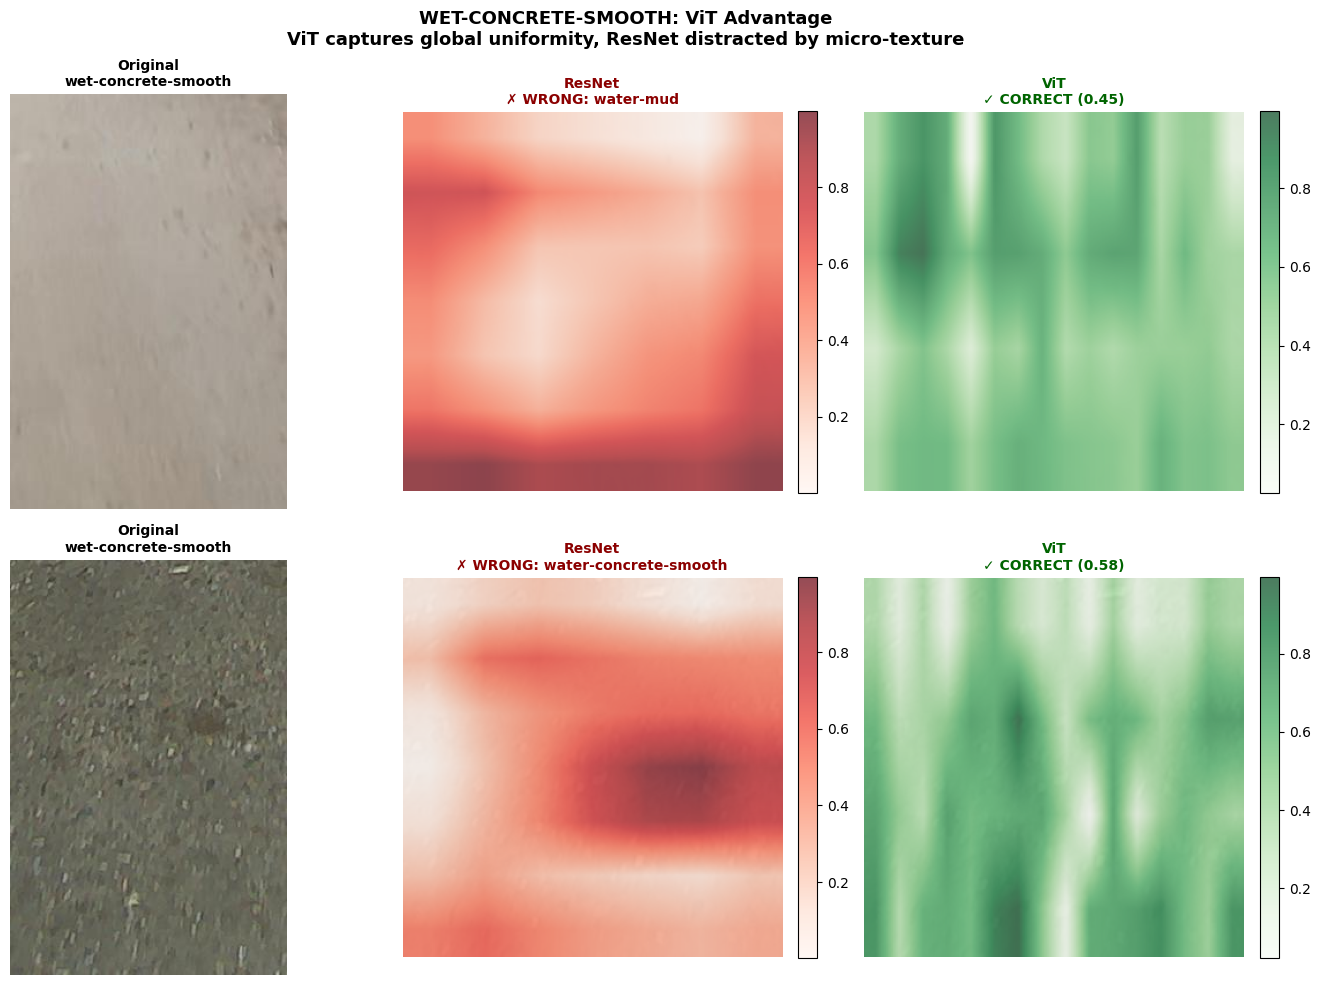

In [97]:
target_class = 'wet-concrete-smooth'
try:
    target_idx = class_names.index(target_class)
except ValueError:
    target_class = 'wet_concrete_smooth'
    target_idx = class_names.index(target_class)

all_class_indices = np.where(test_labels == target_idx)[0]
vit_correct_mask = vit_preds[all_class_indices] == target_idx
resnet_incorrect_mask = resnet_preds[all_class_indices] != target_idx
filtered_indices = all_class_indices[vit_correct_mask & resnet_incorrect_mask]

print(f"Found {len(filtered_indices)} samples where ViT correct, ResNet wrong")

if len(filtered_indices) > 0:
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    num_to_show = min(2, len(filtered_indices))
    fig, axes = plt.subplots(num_to_show, 3, figsize=(14, 5*num_to_show))
    if num_to_show == 1:
        axes = axes.reshape(1, -1)
    
    for row_idx, sample_idx in enumerate(filtered_indices[:num_to_show]):
        img_path, _ = test_dataset.imgs[sample_idx]
        image_pil = Image.open(img_path).convert('RGB')
        image_tensor = val_transform(image_pil).unsqueeze(0).to(device)
        
        resnet_pred_idx = resnet_preds[sample_idx]
        vit_pred_idx = vit_preds[sample_idx]
        resnet_conf = resnet_confidences[sample_idx]
        vit_conf = vit_confidences[sample_idx]
        
        # Column 1: Original Image
        ax = axes[row_idx, 0]
        ax.imshow(image_pil)
        ax.set_title(f"Original\n{target_class}", fontweight='bold', fontsize=10)
        ax.axis('off')
        
        # Column 2: ResNet Attention
        ax = axes[row_idx, 1]
        try:
            resnet_attention = get_resnet_attention(resnet_model, image_tensor, device)
            if resnet_attention is not None:
                resnet_attention_resized = F.interpolate(
                    torch.from_numpy(resnet_attention).unsqueeze(0).unsqueeze(0).float(),
                    size=(224, 224), mode='bilinear'
                ).squeeze().numpy()
                ax.imshow(image_pil, alpha=0.3)
                im = ax.imshow(resnet_attention_resized, cmap='Reds', alpha=0.7)
                ax.set_title(f"ResNet\n✗ WRONG: {class_names[resnet_pred_idx]}", 
                            fontweight='bold', fontsize=10, color='darkred')
                plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        except Exception as e:
            ax.imshow(image_pil)
            ax.set_title(f"ResNet\n✗ WRONG", fontweight='bold', fontsize=10, color='darkred')
        ax.axis('off')
        
        # Column 3: ViT Attention
        ax = axes[row_idx, 2]
        try:
            vit_attention = get_vit_attention(vit_model, image_tensor, device)
            if vit_attention is not None:
                vit_attention_resized = F.interpolate(
                    torch.from_numpy(vit_attention).unsqueeze(0).unsqueeze(0).float(),
                    size=(224, 224), mode='bilinear'
                ).squeeze().numpy()
                ax.imshow(image_pil, alpha=0.3)
                im = ax.imshow(vit_attention_resized, cmap='Greens', alpha=0.7)
                ax.set_title(f"ViT\n✓ CORRECT ({vit_conf:.2f})", 
                            fontweight='bold', fontsize=10, color='darkgreen')
                plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        except Exception as e:
            ax.imshow(image_pil)
            ax.set_title(f"ViT\n✓ CORRECT", fontweight='bold', fontsize=10, color='darkgreen')
        ax.axis('off')
    
    fig.suptitle(f'{target_class.upper()}: ViT Advantage\nViT captures global uniformity, ResNet distracted by micro-texture', 
                fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [92]:
# Print full model structure to find hookable layers
print("="*80)
print("FULL RESNET MODEL STRUCTURE")
print("="*80)
for name, module in resnet_model.named_modules():
    print(f"{name}: {module.__class__.__name__}")

print("\n" + "="*80)
print("FULL VIT MODEL STRUCTURE")
print("="*80)
for name, module in vit_model.named_modules():
    print(f"{name}: {module.__class__.__name__}")

FULL RESNET MODEL STRUCTURE
: ResNetClassifier
backbone: ResNet
backbone.conv1: Conv2d
backbone.bn1: BatchNorm2d
backbone.relu: ReLU
backbone.maxpool: MaxPool2d
backbone.layer1: Sequential
backbone.layer1.0: BasicBlock
backbone.layer1.0.conv1: Conv2d
backbone.layer1.0.bn1: BatchNorm2d
backbone.layer1.0.relu: ReLU
backbone.layer1.0.conv2: Conv2d
backbone.layer1.0.bn2: BatchNorm2d
backbone.layer1.1: BasicBlock
backbone.layer1.1.conv1: Conv2d
backbone.layer1.1.bn1: BatchNorm2d
backbone.layer1.1.relu: ReLU
backbone.layer1.1.conv2: Conv2d
backbone.layer1.1.bn2: BatchNorm2d
backbone.layer2: Sequential
backbone.layer2.0: BasicBlock
backbone.layer2.0.conv1: Conv2d
backbone.layer2.0.bn1: BatchNorm2d
backbone.layer2.0.relu: ReLU
backbone.layer2.0.conv2: Conv2d
backbone.layer2.0.bn2: BatchNorm2d
backbone.layer2.0.downsample: Sequential
backbone.layer2.0.downsample.0: Conv2d
backbone.layer2.0.downsample.1: BatchNorm2d
backbone.layer2.1: BasicBlock
backbone.layer2.1.conv1: Conv2d
backbone.layer2.1.